# Statistical Analysis of Lab Events by Item ID

Detailed analysis of laboratory data grouped by item_id:
- Standard deviation and variance of values
- Statistics on ref_range_lower and ref_range_upper
- Count of measurement units used

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data from gzip compressed CSV
input_csv = Path("../datasets/mimiciv_demo/hosp/labevents.csv.gz")
df = pd.read_csv(input_csv, compression='gzip')

print(f"✅ Data loaded from {input_csv}: {len(df)} rows")
print(f"Available columns: {df.columns.tolist()}")
df.head()

✅ Data loaded from ../datasets/mimiciv_demo/hosp/labevents.csv.gz: 107727 rows
Available columns: ['labevent_id', 'subject_id', 'hadm_id', 'specimen_id', 'itemid', 'order_provider_id', 'charttime', 'storetime', 'value', 'valuenum', 'valueuom', 'ref_range_lower', 'ref_range_upper', 'flag', 'priority', 'comments']


,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
0,172061,10014354,29600294.0,1808066,51277,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,15.4,15.40,%,10.5,15.5,NaN,ROUTINE,NaN
1,172062,10014354,29600294.0,1808066,51279,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,3.35,3.35,m/uL,4.6,6.1,abnormal,ROUTINE,NaN
2,172068,10014354,29600294.0,1808066,52172,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,49.7,49.70,fL,35.1,46.3,abnormal,ROUTINE,NaN
3,172063,10014354,29600294.0,1808066,51301,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,20.3,20.30,K/uL,4.0,10.0,abnormal,ROUTINE,NaN
4,172050,10014354,29600294.0,1808066,51249,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,31.1,31.10,g/dL,32.0,37.0,abnormal,ROUTINE,NaN


In [2]:
# Grouping by item_id and calculating statistics
def calculate_statistics_per_itemid(df):
    """
    Groups by item_id and calculates detailed statistics
    """
    
    def count_uom(serie):
        """Count unique measurement units used"""
        return serie.nunique()
    
    def list_uom(serie):
        """List measurement units with frequency"""
        return serie.value_counts().to_dict()
    
    aggregations = {
        # Statistics on valuenum (numeric)
        'valuenum': ['mean', 'std', 'var', 'min', 'max', 'count'],
        
        # Statistics on value (categorical - count)
        'value': [('value_count', 'count')],
        
        # Statistics on ref_range_lower
        'ref_range_lower': ['mean', 'std', 'var', ('ref_lower_count', 'count')],
        
        # Statistics on ref_range_upper
        'ref_range_upper': ['mean', 'std', 'var', ('ref_upper_count', 'count')],
        
        # Measurement units
        'valueuom': [
            ('uom_unique_count', count_uom),
            ('uom_frequency', list_uom)
        ]
    }
    
    # Grouping
    df_stats = df.groupby('itemid', as_index=False).agg(aggregations)
    
    # Flatten the MultiIndex columns
    df_stats.columns = [
        f"{col[0]}_{col[1]}" if isinstance(col, tuple) and col[1] != ''
        else col[0] if isinstance(col, tuple) 
        else col
        for col in df_stats.columns
    ]
    
    return df_stats

df_stats = calculate_statistics_per_itemid(df)
print(f"✅ Statistics calculated for {len(df_stats)} unique item_ids")
df_stats

✅ Statistics calculated for 498 unique item_ids


,itemid,valuenum_mean,valuenum_std,valuenum_var,valuenum_min,valuenum_max,valuenum_count,value_value_count,ref_range_lower_mean,ref_range_lower_std,ref_range_lower_var,ref_range_lower_ref_lower_count,ref_range_upper_mean,ref_range_upper_std,ref_range_upper_var,ref_range_upper_ref_upper_count,valueuom_uom_unique_count,valueuom_uom_frequency
0,50801,490.214286,71.181228,5066.767196,333.0,592.0,28,28,NaN,NaN,NaN,0,NaN,NaN,NaN,0,1,{'mm Hg': 28}
1,50802,-1.986502,5.777971,33.384953,-25.0,16.0,889,889,NaN,NaN,NaN,0,NaN,NaN,NaN,0,1,{'mEq/L': 889}
2,50803,22.307692,7.352830,54.064103,7.0,33.0,13,13,21.0,0.0,0.0,13,30.0,0.0,0.0,13,1,{'mEq/L': 13}
3,50804,24.165354,6.128200,37.554834,7.0,49.0,889,889,21.0,0.0,0.0,889,30.0,0.0,0.0,889,1,{'mEq/L': 889}
4,50805,2.614286,2.715651,7.374762,0.0,7.0,7,7,0.0,0.0,0.0,7,5.0,0.0,0.0,7,1,{'%': 7}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
493,52425,NaN,NaN,NaN,NaN,NaN,0,1,NaN,NaN,NaN,0,NaN,NaN,NaN,0,0,{}
494,52427,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,0,{}
495,52769,1205.562500,378.979677,143625.595833,440.0,1880.0,16,16,NaN,NaN,NaN,0,NaN,NaN,NaN,0,1,{'#/uL': 16}
496,52955,NaN,NaN,NaN,NaN,NaN,0,1,NaN,NaN,NaN,0,NaN,NaN,NaN,0,0,{}


In [3]:
# Display detailed statistics for the first item_ids
print("=" * 100)
print("DETAILED STATISTICS BY ITEM_ID")
print("=" * 100)

# Select key columns to display
key_columns = [
    'item_id',
    'valuenum_mean', 'valuenum_std', 'valuenum_var', 'valuenum_count',
    'ref_range_lower_mean', 'ref_range_lower_std', 'ref_range_lower_var',
    'ref_range_upper_mean', 'ref_range_upper_std', 'ref_range_upper_var',
    'uom_unique_count'
]

# Filter columns that exist
available_columns = [col for col in key_columns if col in df_stats.columns]
df_stats_view = df_stats[available_columns].copy()

# Round decimals for readability
df_stats_view = df_stats_view.round(4)

print(df_stats_view.head(20))

DETAILED STATISTICS BY ITEM_ID
    valuenum_mean  valuenum_std  valuenum_var  valuenum_count  \
0        490.2143       71.1812     5066.7672              28   
1         -1.9865        5.7780       33.3850             889   
2         22.3077        7.3528       54.0641              13   
3         24.1654        6.1282       37.5548             889   
4          2.6143        2.7157        7.3748               7   
5        104.8515        5.6434       31.8477             101   
6          1.1131        0.0979        0.0096             509   
7        143.4154       55.7829     3111.7341             260   
8         31.5734        7.7255       59.6830             143   
9         10.5077        2.5575        6.5407             143   
10            NaN           NaN           NaN               0   
11         2.4146        1.9307        3.7276             758   
12         0.0000        0.0000        0.0000               6   
13        14.8947       26.1744      685.0994              

In [5]:
# Detailed analysis of measurement units by item_id
print("\n" + "=" * 100)
print("MEASUREMENT UNITS (UOM) ANALYSIS BY ITEM_ID")
print("=" * 100)

uom_analysis = []

for idx, row in df_stats.iterrows():
    item_id = row['itemid']
    
    if isinstance(uom_freq, dict):
        uom_analysis.append({
            'item_id': item_id,
            'uom_unique_count': row['uom_unique_count'],
            'total_samples': row['valuenum_count']
        })

df_uom = pd.DataFrame(uom_analysis)

print("\nTop 15 item_ids with most UOM variety:")
print(df_uom.sort_values('uom_unique_count', ascending=False).head(15).to_string())


MEASUREMENT UNITS (UOM) ANALYSIS BY ITEM_ID


NameError: name 'uom_freq' is not defined

In [6]:
# Save results
output_path = Path("../../outputs/item_id_statistics.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

df_stats.to_csv(output_path, index=False)
print(f"\n✅ Statistics saved to: {output_path}")

# Final summary
print("\n" + "=" * 100)
print("ANALYSIS SUMMARY")
print("=" * 100)
print(f"Total item_ids analyzed: {len(df_stats)}")
print(f"Total samples in dataset: {len(df)}")
print(f"\nGlobal statistics on valuenum:")
print(f"  - Global mean: {df['valuenum'].mean():.4f}")
print(f"  - Global std dev: {df['valuenum'].std():.4f}")
print(f"  - Global variance: {df['valuenum'].var():.4f}")
print(f"\nUnique measurement units in dataset: {df['valueuom'].nunique()}")
print(f"UOM distribution: {df['valueuom'].value_counts().head().to_dict()}")


✅ Statistics saved to: ../../outputs/item_id_statistics.csv

ANALYSIS SUMMARY
Total item_ids analyzed: 498
Total samples in dataset: 107727

Global statistics on valuenum:
  - Global mean: 69.1040
  - Global std dev: 972.4292
  - Global variance: 945618.4851

Unique measurement units in dataset: 49
UOM distribution: {'mg/dL': 20429, 'mEq/L': 17270, '%': 14782, 'K/uL': 8448, 'g/dL': 5500}


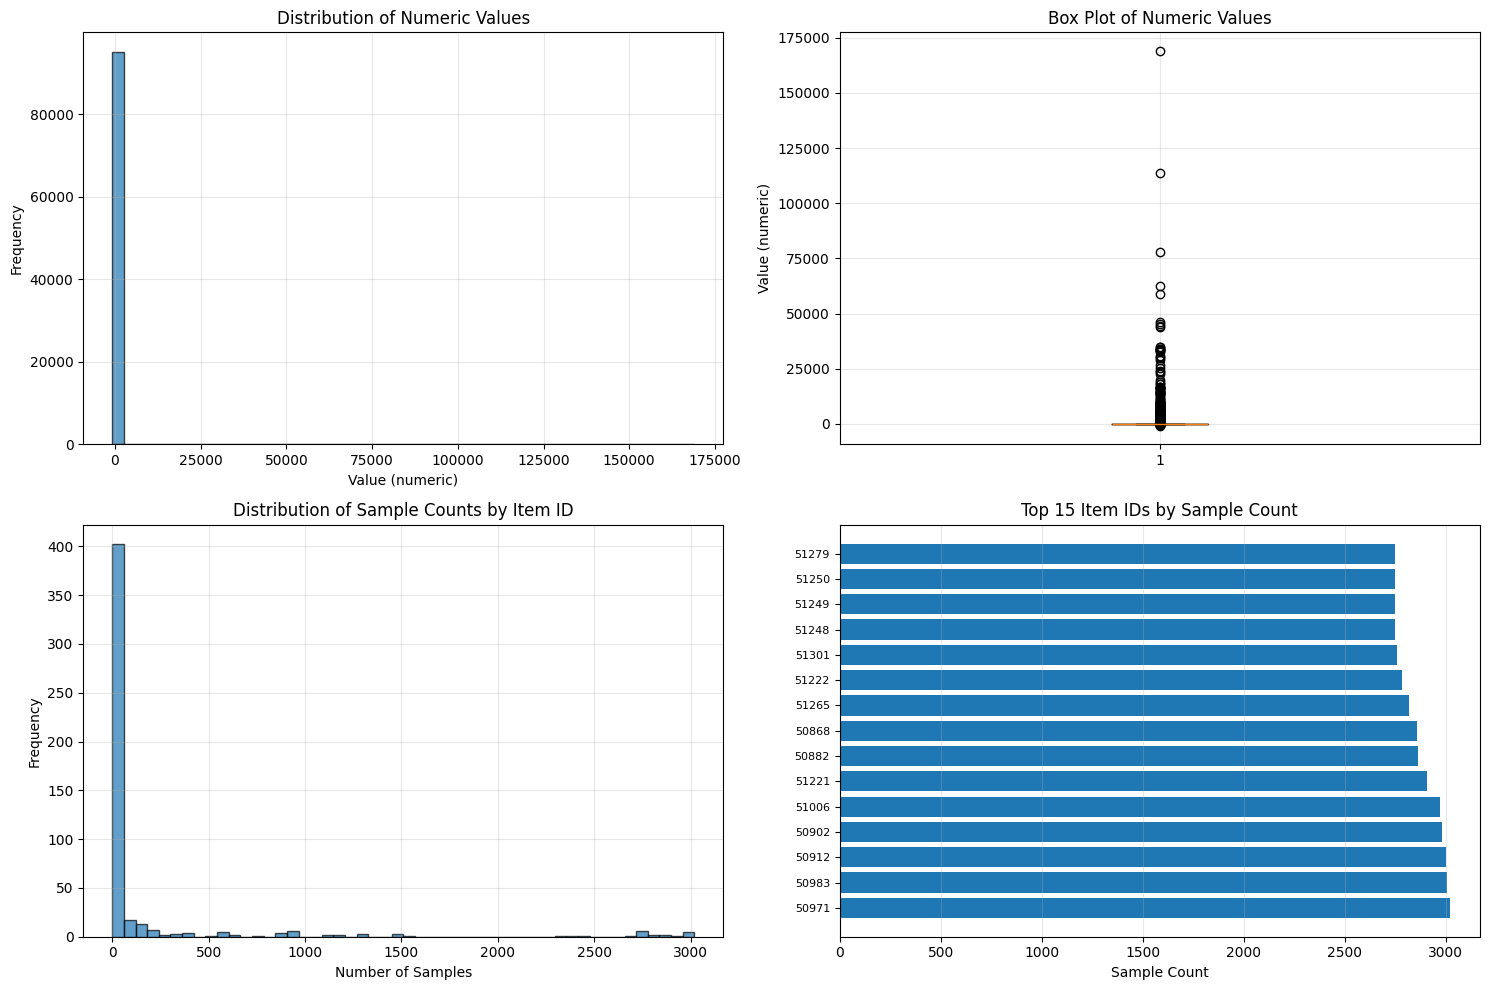

✅ Saved: valuenum_distribution.png


In [8]:
# Visualization 1: Distribution of valuenum across all samples
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram of valuenum
axes[0, 0].hist(df['valuenum'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Value (numeric)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Numeric Values')
axes[0, 0].grid(alpha=0.3)

# Box plot of valuenum
axes[0, 1].boxplot(df['valuenum'].dropna())
axes[0, 1].set_ylabel('Value (numeric)')
axes[0, 1].set_title('Box Plot of Numeric Values')
axes[0, 1].grid(alpha=0.3)

# Distribution of measurements per item_id
axes[1, 0].hist(df_stats['valuenum_count'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Number of Samples')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Sample Counts by Item ID')
axes[1, 0].grid(alpha=0.3)

# Top 15 item_ids by count
top_items = df_stats.nlargest(15, 'valuenum_count')
axes[1, 1].barh(range(len(top_items)), top_items['valuenum_count'].values)
axes[1, 1].set_yticks(range(len(top_items)))
axes[1, 1].set_yticklabels(top_items['itemid'].astype(int).values, fontsize=8)
axes[1, 1].set_xlabel('Sample Count')
axes[1, 1].set_title('Top 15 Item IDs by Sample Count')
axes[1, 1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../../outputs/valuenum_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: valuenum_distribution.png")

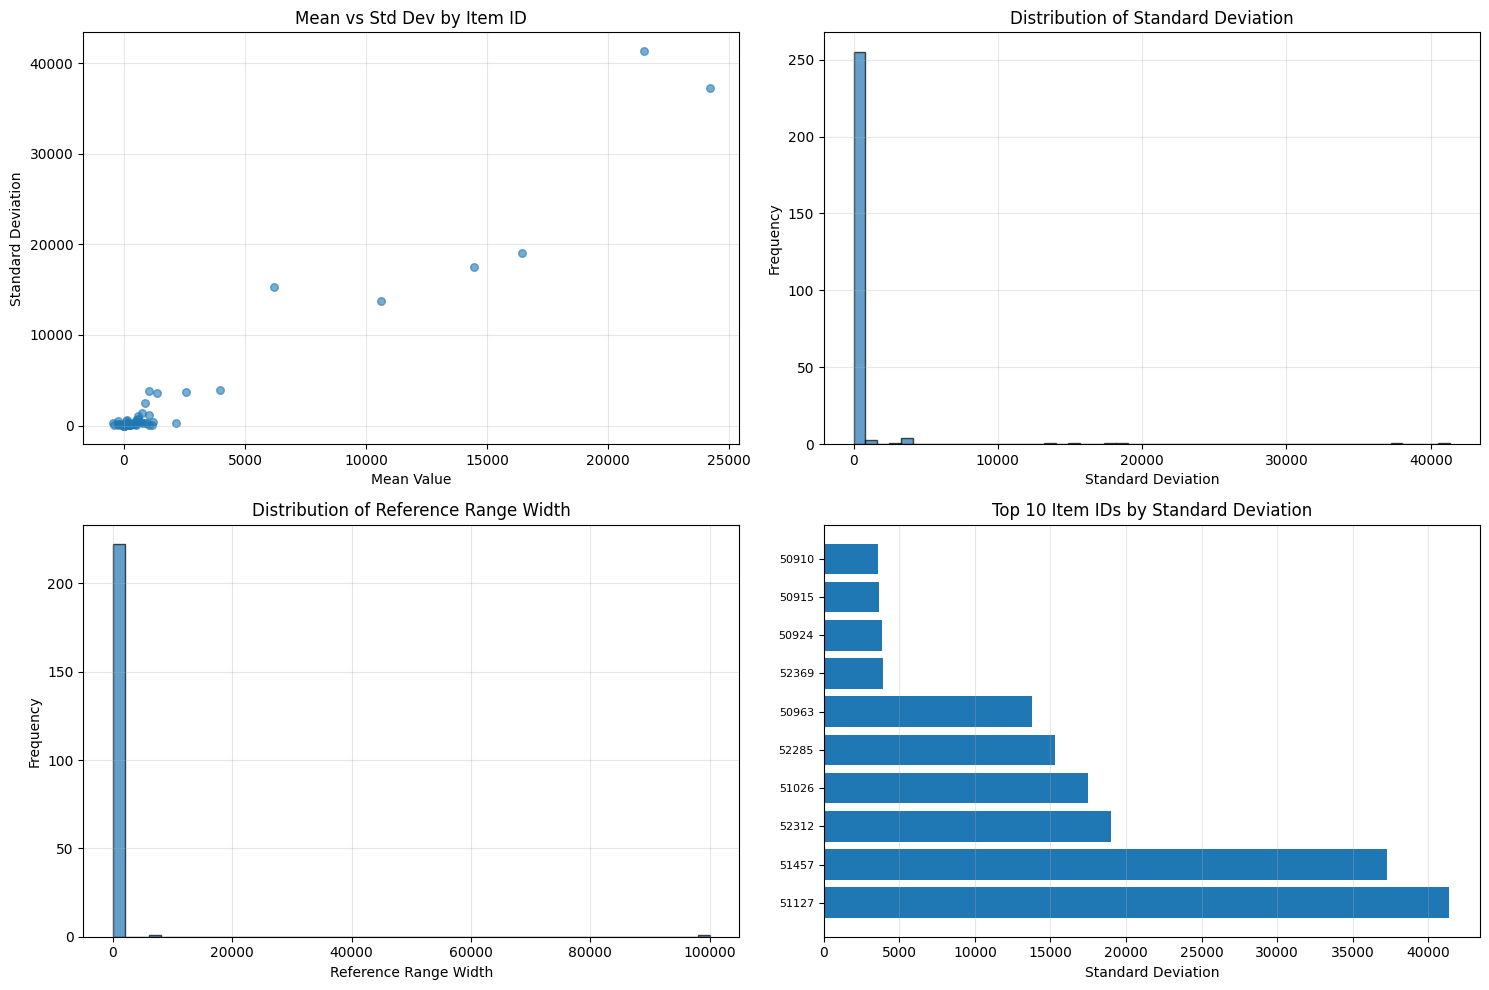

✅ Saved: statistics_per_itemid.png


In [10]:
# Visualization 2: Statistics per item_id
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Scatter: mean vs std dev
axes[0, 0].scatter(df_stats['valuenum_mean'], df_stats['valuenum_std'], alpha=0.6, s=30)
axes[0, 0].set_xlabel('Mean Value')
axes[0, 0].set_ylabel('Standard Deviation')
axes[0, 0].set_title('Mean vs Std Dev by Item ID')
axes[0, 0].grid(alpha=0.3)

# Distribution of std dev
axes[0, 1].hist(df_stats['valuenum_std'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Standard Deviation')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Standard Deviation')
axes[0, 1].grid(alpha=0.3)

# Reference range widths
df_stats['ref_range_width'] = df_stats['ref_range_upper_mean'] - df_stats['ref_range_lower_mean']
axes[1, 0].hist(df_stats['ref_range_width'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Reference Range Width')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Reference Range Width')
axes[1, 0].grid(alpha=0.3)

# Top 10 items with highest std dev
top_std = df_stats.nlargest(10, 'valuenum_std')
axes[1, 1].barh(range(len(top_std)), top_std['valuenum_std'].values)
axes[1, 1].set_yticks(range(len(top_std)))
axes[1, 1].set_yticklabels(top_std['itemid'].astype(int).values, fontsize=8)
axes[1, 1].set_xlabel('Standard Deviation')
axes[1, 1].set_title('Top 10 Item IDs by Standard Deviation')
axes[1, 1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../../outputs/statistics_per_itemid.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: statistics_per_itemid.png")

KeyError: 'uom_unique_count'

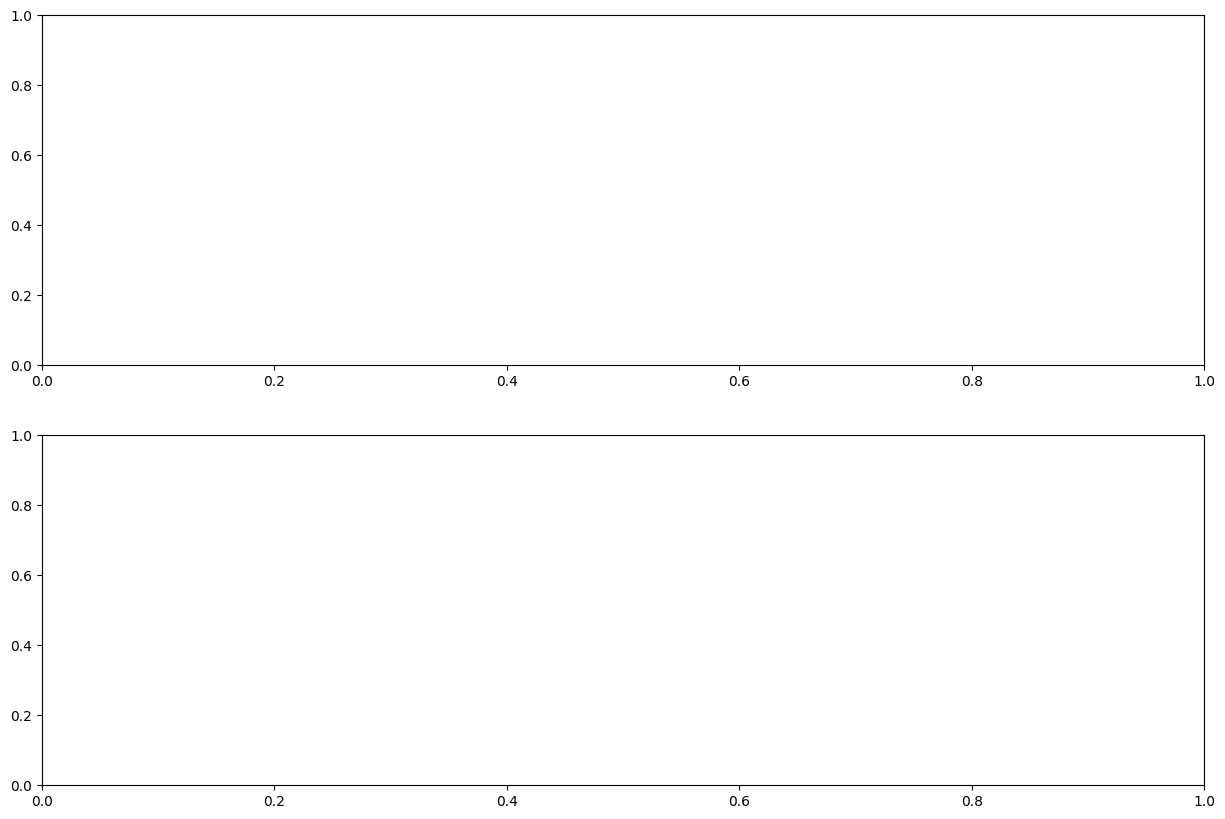

In [11]:
# Visualization 3: Measurement Units Analysis
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Distribution of unique UOM count per item_id
axes[0].hist(df_stats['uom_unique_count'], bins=range(1, int(df_stats['uom_unique_count'].max())+2), 
             edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Unique Units of Measurement')
axes[0].set_ylabel('Frequency (Item IDs)')
axes[0].set_title('Distribution of UOM Variety by Item ID')
axes[0].grid(alpha=0.3)

# Top items with highest UOM variety
top_uom = df_uom.nlargest(15, 'uom_unique_count')
axes[1].barh(range(len(top_uom)), top_uom['uom_unique_count'].values)
axes[1].set_yticks(range(len(top_uom)))
axes[1].set_yticklabels(top_uom['item_id'].astype(int).values, fontsize=8)
axes[1].set_xlabel('Number of Unique Units')
axes[1].set_title('Top 15 Item IDs with Most UOM Variety')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../../outputs/uom_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: uom_analysis.png")